In [1]:
# Load csv as pandas dataframe
import pandas as pd


In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Set headers to mimic a browser request
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:91.0) Gecko/20100101 Firefox/91.0',
    'Accept-Language': 'en-US,en;q=0.5',
    'Accept-Encoding': 'gzip, deflate, br',
    'Connection': 'keep-alive',
    'Upgrade-Insecure-Requests': '1',
    'DNT': '1',  # Do Not Track request header
}

# Function to extract tables from a given URL
def extract_table_from_url(url, required_columns, headers):
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Find all tables with the target class
    tables = soup.find_all('table', class_='BlogTableTiling MyTable')
    
    print(f"Found {len(tables)} tables on {url}")
    
    tablesdf_combined = pd.DataFrame()  # Initialize empty DataFrame for all tables
    i = 0  # Counter to track number of matching tables
    
    # Iterate over found tables
    for table in tables:
        # Get the first row (headers)
        headers_row = table.find_all('tr')[0]
        headers = [td.get_text(strip=True) for td in headers_row.find_all('td')]
        
        # Normalize and remove extra spaces
        headers = [header.replace('\n', ' ').strip() for header in headers]

        # print(f"Extracted headers: {headers}")
        
        # Check if headers match the required columns
        if headers == required_columns:
            print(f"Found matching table {i + 1} on {url}")
            i += 1
            
            # If headers match, convert the table to a pandas DataFrame
            rows = []
            for row in table.find_all('tr')[1:]:
                row_data = []
                for idx, td in enumerate(row.find_all('td')):
                    # Check if it's the "BullishBearish" column (assuming it's the 3rd column based on the example)
                    if idx == 2:
                        bgcolor = td.get('bgcolor', '').lower()  # Get the background color and normalize case
                        if bgcolor == '#ff0000':
                            row_data.append(-1)  # Red color, mark as -1
                        elif bgcolor == '#008000':
                            row_data.append(1)  # Green color, mark as 1
                        else:
                            row_data.append(0)  # No color or other color, mark as 0 (or leave as is)
                    else:
                        row_data.append(td.get_text(strip=True))  # For all other columns
                rows.append(row_data)

            tabledf = pd.DataFrame(rows, columns=headers)
            
            # Concatenate the current DataFrame with the previously combined ones
            tablesdf_combined = pd.concat([tablesdf_combined, tabledf], ignore_index=True)
            
            # print(f"Table {i} extracted: \n{tabledf.head()}")  # Print the first few rows of the extracted table
            
    return tablesdf_combined




# Function to loop through months and years, extracting the required table
def scrape_tables(start_year, end_year, required_columns, headers):
    df_list = []
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    for year in range(start_year, end_year + 1):
        for month in months:
            url = f"https://thepatternsite.com/Blog-{month}{str(year)[-2:]}.html"
            print(f"Scraping {url}")

            # Extract table from the URL
            table_df = extract_table_from_url(url, required_columns, headers)
            
            if table_df is not None:
                df_list.append(table_df)
            else:
                print(f"No matching table found for {url}")
    
    # Concatenate all DataFrames into one
    if df_list:
        final_df = pd.concat(df_list, ignore_index=True)
        return final_df
    else:
        return pd.DataFrame()  # Return empty DataFrame if no tables were found

# Define the required columns for the table
required_columns = ['Symbol', 'Chart Pattern', 'BullishBearish', 'Start', 'End', 'Industry']

# Scrape tables from the blog pages between 2020 and 2024
final_data = scrape_tables(2020, 2025, required_columns, headers)

# Save the final DataFrame to a CSV file
final_data.to_csv('Datasets/scraped_blog_tables.csv', index=False)
print("Tables successfully scraped and saved to 'scraped_blog_tables.csv'")

# extract_table_from_url("https://thepatternsite.com/Blog-Jan20.html", required_columns, headers)


Scraping https://thepatternsite.com/Blog-Jan20.html
Found 23 tables on https://thepatternsite.com/Blog-Jan20.html
Found matching table 1 on https://thepatternsite.com/Blog-Jan20.html
Found matching table 2 on https://thepatternsite.com/Blog-Jan20.html
Found matching table 3 on https://thepatternsite.com/Blog-Jan20.html
Found matching table 4 on https://thepatternsite.com/Blog-Jan20.html
Scraping https://thepatternsite.com/Blog-Feb20.html
Found 22 tables on https://thepatternsite.com/Blog-Feb20.html
Found matching table 1 on https://thepatternsite.com/Blog-Feb20.html
Found matching table 2 on https://thepatternsite.com/Blog-Feb20.html
Found matching table 3 on https://thepatternsite.com/Blog-Feb20.html
Found matching table 4 on https://thepatternsite.com/Blog-Feb20.html
Scraping https://thepatternsite.com/Blog-Mar20.html
Found 33 tables on https://thepatternsite.com/Blog-Mar20.html
Found matching table 1 on https://thepatternsite.com/Blog-Mar20.html
Found matching table 2 on https://the

In [3]:
final_data

,Symbol,Chart Pattern,BullishBearish,Start,End,Industry
0,ACN,"Triangle, symmetrical",1,12/19/2019,01/30/2020,IT Services
1,ADS,Broadening top,-1,12/13/2019,01/24/2020,Information Services
2,AVY,Triple bottom,1,12/03/2019,01/27/2020,Packaging and Container
3,CMTL,Dead-cat bounce,-1,01/29/2020,01/29/2020,Telecom. Equipment
4,CSOD,Pipe top,-1,01/13/2020,01/21/2020,E-Commerce
...,...,...,...,...,...,...
10726,TPR,Head-and-shoulders top,0,02/06/2025,02/26/2025,Apparel
10727,TGT,"Double Top, Eve and Adam",0,01/10/2025,01/28/2025,Retail Store
10728,TDOC,"Double Top, Adam and Adam",0,02/10/2025,02/14/2025,Healthcare Information
10729,TDY,"Double Bottom, Adam and Adam",0,02/14/2025,02/24/2025,Aerospace/Defense


In [4]:


# Load csv as pandas dataframe
# cleanedPatternDf = pd.read_csv('Extracted Cleaned data of 2019 - 2024 chart patterns by Mr. Bulkowski.csv')
cleanedPatternDf = pd.read_csv('Datasets/scraped_blog_tables.csv')
cleanedPatternDf

,Symbol,Chart Pattern,BullishBearish,Start,End,Industry
0,ACN,"Triangle, symmetrical",1,12/19/2019,01/30/2020,IT Services
1,ADS,Broadening top,-1,12/13/2019,01/24/2020,Information Services
2,AVY,Triple bottom,1,12/03/2019,01/27/2020,Packaging and Container
3,CMTL,Dead-cat bounce,-1,01/29/2020,01/29/2020,Telecom. Equipment
4,CSOD,Pipe top,-1,01/13/2020,01/21/2020,E-Commerce
...,...,...,...,...,...,...
10726,TPR,Head-and-shoulders top,0,02/06/2025,02/26/2025,Apparel
10727,TGT,"Double Top, Eve and Adam",0,01/10/2025,01/28/2025,Retail Store
10728,TDOC,"Double Top, Adam and Adam",0,02/10/2025,02/14/2025,Healthcare Information
10729,TDY,"Double Bottom, Adam and Adam",0,02/14/2025,02/24/2025,Aerospace/Defense


In [5]:
# create a new df with the xolumn number of days from start to end of the pattern
patternDf = cleanedPatternDf.copy()
patternDf['Start'] = pd.to_datetime(patternDf['Start'])
patternDf['End'] = pd.to_datetime(patternDf['End'])
patternDf['Days'] = (patternDf['End'] - patternDf['Start']).dt.days
patternDf.head()


,Symbol,Chart Pattern,BullishBearish,Start,End,Industry,Days
0,ACN,"Triangle, symmetrical",1,2019-12-19,2020-01-30,IT Services,42
1,ADS,Broadening top,-1,2019-12-13,2020-01-24,Information Services,42
2,AVY,Triple bottom,1,2019-12-03,2020-01-27,Packaging and Container,55
3,CMTL,Dead-cat bounce,-1,2020-01-29,2020-01-29,Telecom. Equipment,0
4,CSOD,Pipe top,-1,2020-01-13,2020-01-21,E-Commerce,8


In [6]:
# get the min max and mean of the days
minDays = patternDf['Days'].min()
print("Min Days: ", minDays)

maxDaysDays = patternDf['Days'].max()
print("Max Days: ", maxDaysDays)

meanDays = patternDf['Days'].mean()
print("Mean Days: ", meanDays)

Min Days:  0
Max Days:  311
Mean Days:  22.283384586711396


In [7]:
# number of rows in the dataframe
numRows = len(patternDf)
print("Number of rows: ", numRows)

Number of rows:  10731


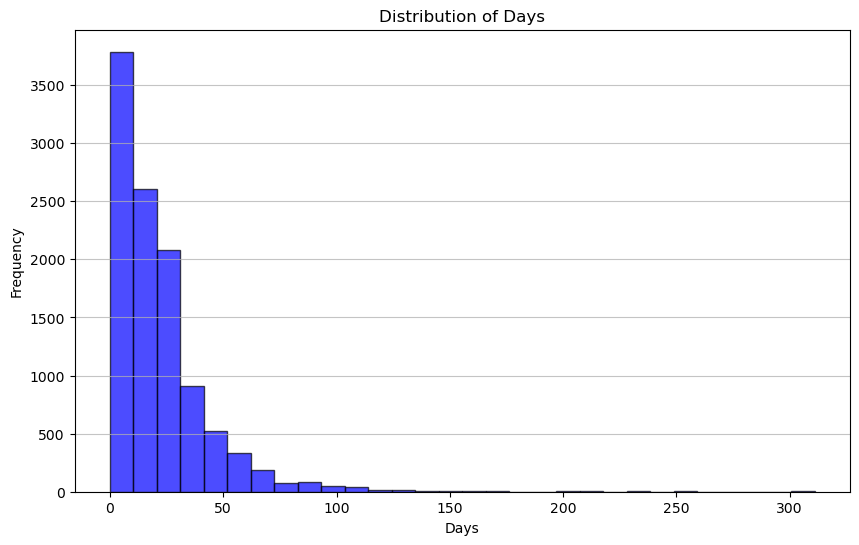

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming you have loaded your DataFrame as patternDf
# patternDf = pd.read_csv('your_data.csv') # Example of loading data if needed

# Plot a histogram to visualize the distribution of 'Days' data
plt.figure(figsize=(10, 6))
plt.hist(patternDf['Days'], bins=30, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of Days')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.show()


In [9]:
# get the number of occurances of each values in the Symbol column
numberofTimes=cleanedPatternDf['Symbol'].value_counts()
numberofTimes

Symbol
HOV     42
AA      39
CENX    38
AMWD    36
OUT     35
        ..
XLY      1
XLP      1
XLE      1
XLV      1
SGI      1
Name: count, Length: 676, dtype: int64

In [10]:
#  get all the unique values in the Chart Pattern column 
uniquePatterns=cleanedPatternDf['Chart Pattern'].value_counts()
uniquePatterns.head(30)

Chart Pattern
Pipe bottom                     1536
Double Bottom, Adam and Adam     716
Pipe top                         664
Ugly double bottom               628
Triangle, symmetrical            564
Double Top, Adam and Adam        515
Triple top                       411
Triple bottom                    395
Head-and-shoulders top           393
Head-and-shoulders bottom        362
Dead-cat bounce                  357
Double Top, Adam and Eve         330
Double Top, Eve and Eve          325
Double Bottom, Eve and Adam      318
Double Top, Eve and Adam         276
Double Bottom, Eve and Eve       260
Flag, high and tight             247
Double Bottom, Adam and Eve      242
Broadening top                   216
Diamond top                      174
Triangle, ascending              146
Broadening bottom                141
Three Rising Valleys             126
Triangle, descending             117
Horn top                          96
Diamond bottom                    85
Rectangle top           

#### Selected patterns

Double Bottom, Adam and Adam 518

Triangle, symmetrical 483

Double Top, Adam and Adam 295

Double Bottom, Eve and Adam 208

Head-and-shoulders bottom 291

Head-and-shoulders top 263

Cup with handle 61


In [11]:
#  number of occurances of the Cup with handle pattern  
cupWithHandle=cleanedPatternDf['Chart Pattern'].str.contains('Cup with handle').sum()
cupWithHandle

66

In [12]:
# search for the row with the symbol 'AAPL' in numberofTimes
numberofTimes.loc['NVDA']


29

In [13]:
# get the symbol as a list from numberofTimes
symbols = numberofTimes.index.tolist()
symbols

['HOV',
 'AA',
 'CENX',
 'AMWD',
 'OUT',
 'WLK',
 'SCS',
 'CBT',
 'EXP',
 'SWN',
 'NSP',
 'FLS',
 'GFF',
 'FCX',
 'TDOC',
 'TPX',
 'IPG',
 'CLF',
 'MTRX',
 'CLNE',
 'SUM',
 'CMTL',
 'ALB',
 'OMC',
 'MTSI',
 'FRD',
 'DDD',
 'APOG',
 'SAIA',
 'IBP',
 'MTRN',
 'APA',
 'SKX',
 'CF',
 'RL',
 'PNW',
 '^DJT',
 'AEO',
 'BECN',
 'OXM',
 'IIIN',
 'M',
 'NVDA',
 'VFC',
 'KWR',
 'ADTN',
 'BA',
 'LXU',
 'MCHX',
 'GPS',
 'DVN',
 'RAMP',
 'ALRM',
 'SLCA',
 'GS',
 'EPAM',
 'BMI',
 'ZBRA',
 'CAL',
 'EXPD',
 '^DJU',
 'MU',
 'ARCB',
 'CTS',
 'NBR',
 'TKR',
 'MHO',
 'MUR',
 'SLB',
 'KLIC',
 'SCCO',
 'AGO',
 'RIG',
 'DGX',
 'NWL',
 'ANF',
 'BKNG',
 'LEN',
 'FLEX',
 'DECK',
 'TPR',
 'HON',
 'TECH',
 'CX',
 'TDC',
 'AVNT',
 'WSM',
 'LOW',
 'KALU',
 'UGI',
 'GD',
 'FORM',
 'BRC',
 'CE',
 'SRDX',
 'ROK',
 'KLAC',
 'OXY',
 'JWN',
 'IPI',
 'PPG',
 'INTC',
 'WWW',
 'CLS',
 'AVA',
 'LEG',
 'BLDR',
 'HL',
 'FMC',
 'RGA',
 'POR',
 'CROX',
 'OGE',
 'CR',
 'RES',
 'PTEN',
 'VMC',
 'HP',
 'LZB',
 'RMBS',
 'PANW',
 'GPR

In [14]:
import yfinance as yf
import os
from datetime import datetime
from tqdm import tqdm

tickers = symbols  # Ensure 'symbols' is defined as a list of stock tickers
output_directory = 'Datasets/OHLC data'
start_date = '2019-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')
error_symbols = set()

# Create the output directory if it doesn't exist
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Use tqdm to add a progress bar
for ticker in tqdm(tickers, desc="Downloading stock data", unit="stock"):
    try:
        data_obj = yf.Ticker(ticker)
        data = data_obj.history(start=start_date, end=end_date)
        
        if data.empty:
            print(f"No data found for {ticker}")
            error_symbols.add(ticker)
        data['Date'] = pd.to_datetime(data['Date'], utc=True)
        data['Date'] = data['Date'].dt.date
        data = data[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
        data.to_csv(f'{output_directory}/{ticker}.csv')
    except Exception as e:
        print(f"\nError downloading data for {ticker}: {e}")
        error_symbols.add(ticker)



Error downloading data for HOV: 'Date'



Error downloading data for AA: 'Date'



Error downloading data for CENX: 'Date'

Error downloading data for AMWD: 'Date'



Error downloading data for OUT: 'Date'

Error downloading data for WLK: 'Date'



Error downloading data for SCS: 'Date'


...


Error downloading data for SSO: 'Date'

Error downloading data for SH: 'Date'



Error downloading data for SDS: 'Date'

Error downloading data for XLY: 'Date'



Error downloading data for XLP: 'Date'

Error downloading data for XLE: 'Date'



Error downloading data for XLV: 'Date'



Error downloading data for SGI: 'Date'


In [25]:
sample_ohlc_data = pd.read_csv('Datasets/OHLC data/NVDA.csv')
sample_ohlc_data['Date'] = pd.to_datetime(sample_ohlc_data['Date'], utc=True)
sample_ohlc_data['Date'] = sample_ohlc_data['Date'].dt.date

sample_ohlc_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2019-01-02,3.239415,3.433819,3.224785,3.377779,508752000,0.0,0.0
1,2019-01-03,3.317523,3.351495,3.166265,3.173704,705552000,0.0,0.0
2,2019-01-04,3.246854,3.415222,3.216106,3.377036,585620000,0.0,0.0
3,2019-01-07,3.434316,3.592765,3.382987,3.555818,709160000,0.0,0.0
4,2019-01-08,3.637398,3.639630,3.394641,3.467294,786016000,0.0,0.0


In [27]:
files = os.listdir('Datasets/OHLC data')
# loop through each file in the "OHLC data" folder and udate the date column to datetime
for file in files:
    data = pd.read_csv('Datasets/OHLC data/'+file)
    data['Date'] = pd.to_datetime(data['Date'], utc=True)
    data['Date'] = data['Date'].dt.date
    
    # only have the open, high, low, close and volume columns
    data = data[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    
    data.to_csv('Datasets/OHLC data/'+file, index=False)

In [28]:
# import os
# import yfinance as yf
# import pandas as pd
# from datetime import datetime
# from tqdm import tqdm

# # Get today's date
# end_date = datetime.today().strftime('%Y-%m-%d')

# # Set to store symbols with errors
# error_symbols = set()

# # Create the "OHLC data" folder if it doesn't exist
# output_directory = 'Datasets/OHLC data'
# os.makedirs(output_directory, exist_ok=True)  # Creates the directory if it doesn't exist

# # Assuming numberofTimes is already defined as a DataFrame
# for symbol in tqdm(numberofTimes.index, desc="Downloading Data", unit="symbol"):
#     try:
#         # Download data with end date set to today's date
#         data = yf.download(symbol, start='2019-01-01', end=end_date, progress=False)
        
#         # Check if data is empty
#         if data.empty:
#             # print(f"No data found for {symbol}. It may be delisted or unavailable.")
#             error_symbols.add(symbol)  # Add to error set
#             continue
        
#         # convert the date to datetime
        
        
#         # Save data to a CSV file
#         data.to_csv(f'{output_directory}/{symbol}.csv')  # Save in the created folder
        
#     except Exception as e:
#         # print(f"Failed to download {symbol}: {str(e)}")
#         error_symbols.add(symbol)  # Add to error set

# # Print the symbols that encountered errors
# if error_symbols:
#     print("Symbols with download errors:")
#     print(error_symbols)
# else:
#     print("All symbols downloaded successfully.")


In [29]:
#  check for the empty csv files in the "OHLC data" folder
import os
import pandas as pd

# get the list of all the files in the "OHLC data" folder
files = os.listdir('Datasets/OHLC data')

emptyFiles = []

# check for the empty csv files in the "OHLC data" folder
for file in files:
    data = pd.read_csv('Datasets/OHLC data/'+file)
    if data.empty:
        # add the symbol of the empty csv file to the emptyFiles list
        emptyFiles.append(file)
        

print(emptyFiles)

['ANTM.csv', 'ASNA.csv', 'AYX.csv', 'BIG.csv', 'BLL.csv', 'BRKS.csv', 'CDAY.csv', 'CLR.csv', 'CONN.csv', 'CREE.csv', 'CTXS.csv', 'DO.csv', 'DRQ.csv', 'EIGI.csv', 'EPAY.csv', 'ETFC.csv', 'FB.csv', 'FFG.csv', 'FISV.csv', 'FLIR.csv', 'FOE.csv', 'GPS.csv', 'HAYN.csv', 'HSC.csv', 'IVC.csv', 'JCOM.csv', 'MDCA.csv', 'MLHR.csv', 'MNDT.csv', 'MRO.csv', 'MYL.csv', 'NBL.csv', 'NCR.csv', 'NEWR.csv', 'NXGN.csv', 'PICO.csv', 'PKI.csv', 'PRFT.csv', 'PXD.csv', 'REV.csv', 'SMAR.csv', 'SPLK.csv', 'SWN.csv', 'TLRD.csv', 'XLNX.csv']


In [30]:
# number of empty files
len(emptyFiles)

45

In [31]:

# Normalize and remove the .CSV extension
emptyFiles = [symbol.strip().upper().replace('.CSV', '').replace('.CSV', '') for symbol in emptyFiles]


In [32]:
import subprocess
import json
import pandas as pd
import os
from urllib.parse import urlencode
from datetime import datetime

def get_data(stock_id):
    try:
        url = f'https://api.investing.com/api/financialdata/historical/{stock_id}'
        params = {
            'start-date': '2020-07-01',
            'end-date': '2024-08-31',
            'time-frame': 'Daily',
            'add-missing-rows': 'false'
        }

        cnfg = ['curl', '-A', 'Chrome/128.0.0.0', '-H', 'domain-id: www', '-G', url, '-d', urlencode(params)]
        output = subprocess.run(cnfg, capture_output=True).stdout.decode()
        return json.loads(output)
    except Exception as e:
        print(f"Error fetching data for {stock_id}: {str(e)}")
        return None

def save_data_to_csv(stock_id, stock_data, folder_path="Datasets/OHLC data"):
    os.makedirs(folder_path, exist_ok=True)
    
    columns = ['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Date']
    data_rows = []

    # Parse and format the data into a list of dictionaries
    for entry in stock_data.get('data', []):
        date = datetime.utcfromtimestamp(entry['rowDateRaw']).strftime('%Y-%m-%d %H:%M:%S+00:00')
        data_rows.append({
            'Price': entry['last_closeRaw'],
            'Adj Close': entry['last_closeRaw'],
            'Close': entry['last_closeRaw'],
            'High': entry['last_maxRaw'],
            'Low': entry['last_minRaw'],
            'Open': entry['last_openRaw'],
            'Volume': entry['volumeRaw'],
            'Ticker': stock_id,
            'Date': date
        })

    df = pd.DataFrame(data_rows, columns=columns)
    
    file_path = os.path.join(folder_path, f"{stock_id}.csv")
    
    df.to_csv(file_path, index=False)


In [33]:
stocks = {
    'WIRE': '17555',   # Encore Wire Corp
    'CSOD': '15833',   # Cornerstone OnDemand Inc
    'BBBY': '6389',   # Bed Bath & Beyond Inc
    'STMP': '17267',   # Stamps.com Inc
    'RE': '20171',     # Everest Re Group Ltd (assuming you meant Everest Re)
    'COG': '13835',    # Cabot Oil & Gas Corporation
    'KBAL': '16443',   # Kimball International, Inc.
    'ADS': '32507',    # Alliance Data Systems Corp
    'ERA': '41207',    # Era Group Inc
    'NWY': '8130',     # New York & Company Inc
    'ANTM': '958110',   # Anthem Inc
    'SLCA': '29673',  # U.S. Silica Holdings Inc
    'ABC': '8060',    # AmerisourceBergen Corp
    'NVTA': '',  # Invitae Corp
    'XLNX': '',   # Xilinx Inc
    'CHS': '',     # Chico's FAS Inc.
    'ASNA': '',    # Ascena Retail Group
    'CLR': '111508',   # Continental Resources Inc.
    'FLIR': '3038',    # FLIR Systems Inc
    'HSC': '20517',    # Harsco Corp
    'AJRD': '17292',   # Aerojet Rocketdyne Holdings Inc
    'AYX': '159875',   # Alteryx, Inc
    'CREE': '3021',    # Cree Inc
    'LAWS': '17022',   # Lawson Products
    'TLRD': '28820',   # Tailored Brands Inc
    'CONN': '2969',    # Conn's Inc
    'REV': '2560',     # Revlon Inc
    'JCP': '20306',    # J.C. Penney Company Inc
    'NBL': '2971',     # Noble Energy Inc.
    'AEL': '20560',    # American Equity Investment Life Holding
    'CY': '20461',     # Cypress Semiconductor
    'IVC': '2888',     # Invacare Corp.
    'FFG': '17260',    # FBL Financial Group
    'POL': '21312',    # PolyOne Corp
    'MDC': '24784',    # MDC Holdings Inc.
    'EIGI': '26314',   # Endurance International Group Holdings
    'NXGN': '115196',  # NextGen Healthcare Inc
    'AXE': '20499',    # Anixter International Inc
    'PICO': '24805',   # PICO Holdings
    'JCOM': '17282',   # J2 Global Inc.
    'MYL': '11510',    # Mylan Laboratories Inc.
    'MLHR': '2704',    # Miller, Herman Inc.
    'FOE': '20616',    # Ferro Corp
    'CLGX': '25655',   # CoreLogic Inc
    'FEYE': '988464'   # FireEye Inc
}


In [34]:
for ticker, stock_id in stocks.items():
    data = get_data(stock_id)
    print (data)
    # if data is not none or null
    if data.get('data'):
        save_data_to_csv(ticker, data)
        
    else:
        print(f"No data found for {ticker} with stock ID {stock_id}")

{'data': [{'direction_color': 'greenFont', 'rowDate': 'Jul 01, 2024', 'rowDateRaw': 1719792000, 'rowDateTimestamp': '2024-07-01T00:00:00Z', 'last_close': '289.84', 'last_open': '289.95', 'last_max': '289.99', 'last_min': '289.65', 'volume': '1.39M', 'volumeRaw': 1392153, 'change_precent': '0.00', 'last_closeRaw': '289.83999633789062', 'last_openRaw': '289.95001220703125', 'last_maxRaw': '289.98999023437500', 'last_minRaw': '289.64999389648438', 'change_precentRaw': 0.0034536680429042444}, {'direction_color': 'greenFont', 'rowDate': 'Jun 28, 2024', 'rowDateRaw': 1719532800, 'rowDateTimestamp': '2024-06-28T00:00:00Z', 'last_close': '289.83', 'last_open': '289.77', 'last_max': '289.94', 'last_min': '289.75', 'volume': '1.23M', 'volumeRaw': 1234273, 'change_precent': '0.03', 'last_closeRaw': '289.82998657226562', 'last_openRaw': '289.76998901367188', 'last_maxRaw': '289.94000244140625', 'last_minRaw': '289.75000000000000', 'change_precentRaw': 0.02760537437985332}, {'direction_color': 'gre

C:\Users\gwiku\AppData\Local\Temp\ipykernel_29784\4240947744.py:33: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  date = datetime.utcfromtimestamp(entry['rowDateRaw']).strftime('%Y-%m-%d %H:%M:%S+00:00')


{'data': [{'direction_color': 'greenFont', 'rowDate': 'Oct 14, 2021', 'rowDateRaw': 1634169600, 'rowDateTimestamp': '2021-10-14T00:00:00Z', 'last_close': '57.49', 'last_open': '57.49', 'last_max': '57.51', 'last_min': '57.48', 'volume': '3.74M', 'volumeRaw': 3742462, 'change_precent': '0.02', 'last_closeRaw': '57.49000167846680', 'last_openRaw': '57.49000167846680', 'last_maxRaw': '57.50999832153320', 'last_minRaw': '57.47999954223633', 'change_precentRaw': 0.017401072216639765}, {'direction_color': 'greenFont', 'rowDate': 'Oct 13, 2021', 'rowDateRaw': 1634083200, 'rowDateTimestamp': '2021-10-13T00:00:00Z', 'last_close': '57.48', 'last_open': '57.43', 'last_max': '57.49', 'last_min': '57.43', 'volume': '1.63M', 'volumeRaw': 1631924, 'change_precent': '0.09', 'last_closeRaw': '57.47999954223633', 'last_openRaw': '57.43000030517578', 'last_maxRaw': '57.49000167846680', 'last_minRaw': '57.43000030517578', 'change_precentRaw': 0.0870611819516929}, {'direction_color': 'greenFont', 'rowDate'

In [35]:
# coppy the error_symbols set to a new set
all_error_symbols = error_symbols.copy()

# convert the emptyFiles list to a set and append it to the all_error_symbols set
all_error_symbols.update(set(emptyFiles))

# number of symbols with errors
print(len(all_error_symbols))

print("Symbols with download errors:")
print(all_error_symbols)

676
Symbols with download errors:
{'BERY', 'TDOC', 'LXU', 'EG', 'SPLK', 'SAND', 'EPAM', 'ASGN', 'NVDA', 'GPRO', 'BAH', 'PXD', 'EWY', 'ERA', 'CTS', 'MAS', 'OGE', 'RTX', 'CPB', 'HQY', 'LNC', 'BECN', 'SLB', 'CNP', 'FE', 'IBKR', 'ILMN', 'DTE', 'WMT', 'UNH', 'EIX', 'FLS', 'CI', 'ROG', 'SSO', 'AME', 'SAIC', 'SCHW', 'CTXS', 'BSX', 'SOXX', 'CNX', '^DJU', 'SCS', 'DOX', 'WPM', 'SEE', 'INTU', 'AWI', 'HNI', 'GGG', 'NKE', 'INOV', 'OLN', 'HHS', 'CF', 'FDX', 'LLY', 'A', 'IXN', 'SLCA', 'IEX', 'FDS', 'EIS', 'OR', 'PHO', 'XEL', 'AYX', 'LMT', 'PKG', 'AYI', 'FTV', 'NSP', 'EL', 'FLIR', 'EXPD', 'ALRM', 'ABM', 'PCG', 'KLAC', 'WSO', 'NFG', 'FIS', 'KEYS', 'VAL', 'TOL', 'CTAS', 'FTNT', 'UHAL', 'NEWR', 'JCP', 'JAZZ', 'LH', 'CMI', 'WLK', 'EWG', 'NEE', 'KMT', 'PATK', 'CSGS', 'FIVN', 'BSET', 'ZBRA', 'IPAR', 'EWP', 'NOW', 'ON', 'TUR', 'MRK', 'SCI', 'COTY', 'NOVT', 'HSY', 'EOG', 'AEE', 'LPLA', 'ARW', 'ITA', 'TZOO', 'DBA', '^DJI', 'VC', 'ACN', 'IVC', 'PICO', 'MUR', 'AMTD', 'BCO', 'MMM', 'EWA', 'MRO', 'CNO', 'CL', 'BBW

In [36]:
# loop through cleanedPatternDf rows and check if the data range of each pattern data available in the OHLC data in the "OHLC data" folder files , if not create a list of such symbols
symbols_with_half_data_error = []
for index, row in cleanedPatternDf.iterrows():
    symbol = row['Symbol']
    # check if the symbol is NOT in the all_error_symbols set
    if symbol not in all_error_symbols:
        # get the data of the symbol from the "OHLC data" folder
        data = pd.read_csv(f'Datasets/OHLC data/{symbol}.csv')
        
        data['Date'] = pd.to_datetime(data['Date'])
        row['Start'] = pd.to_datetime(row['Start'])
        row['End'] = pd.to_datetime(row['End'])
        #  check if the start and end date range of the row is available in the data
        if data[(data['Date'] >= row['Start']) & (data['Date'] <= row['End'])].empty:
            symbols_with_half_data_error.append(symbol)
            print(f"Symbol {symbol} has missing data for the range {row['Start']} to {row['End']}")
        


In [37]:
print(len(symbols_with_half_data_error))
print(symbols_with_half_data_error)


0
[]


In [38]:
patternDf['Symbol'] = patternDf['Symbol'].str.strip().str.upper()
all_error_symbols = [symbol.strip().upper() for symbol in all_error_symbols]

In [39]:
# Get the number of rows for each chart pattern of any symbol that has an empty csv file
pattern_count = patternDf[patternDf['Symbol'].isin(all_error_symbols)]['Chart Pattern'].value_counts()

print("Pattern counts for symbols with empty CSV files:", pattern_count)


Pattern counts for symbols with empty CSV files: Chart Pattern
Pipe bottom                                    1536
Double Bottom, Adam and Adam                    716
Pipe top                                        664
Ugly double bottom                              628
Triangle, symmetrical                           564
Double Top, Adam and Adam                       515
Triple top                                      411
Triple bottom                                   395
Head-and-shoulders top                          393
Head-and-shoulders bottom                       362
Dead-cat bounce                                 357
Double Top, Adam and Eve                        330
Double Top, Eve and Eve                         325
Double Bottom, Eve and Adam                     318
Double Top, Eve and Adam                        276
Double Bottom, Eve and Eve                      260
Flag, high and tight                            247
Double Bottom, Adam and Eve                     242
B

In [40]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Set headers to mimic a browser request
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:91.0) Gecko/20100101 Firefox/91.0',
    'Accept-Language': 'en-US,en;q=0.5',
    'Accept-Encoding': 'gzip, deflate, br',
    'Connection': 'keep-alive',
    'Upgrade-Insecure-Requests': '1',
    'DNT': '1',  # Do Not Track request header
}

# Function to extract full stock names from a given URL based on short names
def extract_full_names_from_url(url, short_names, headers):
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    print(f"Scraping {url}")

    full_names = {}

    # Iterate over the short names and find their full names in the HTML
    for short_name in short_names.copy():  # Copy the list to avoid modifying during iteration
        # Search for the short name in the text
        entry = soup.find('div', text=lambda x: x and short_name in x)
        if entry:
            # Get the bold text (full name)
            bold_text = entry.find('span', style=lambda x: x and 'font-weight: bold;' in x)
            if bold_text:
                full_names[short_name] = bold_text.text.strip()
                print(f"Found full name for {short_name}: {full_names[short_name]}")
                # remove the found short name from the list
                short_names.remove(short_name)

    return full_names

# Function to loop through months and years, extracting full names
def scrape_full_names(start_year, end_year, short_names, headers):
    all_full_names = {}
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    
    short_names_copy = short_names.copy()  # Create a copy of the list to avoid modifying the original

    for year in range(start_year, end_year + 1):
        for month in months:
            url = f"https://thepatternsite.com/Blog-{month}{str(year)[-2:]}.html"
            
            # Check if the short names list is empty, break if it is
            if not short_names_copy:
                break
            
            # Extract full names from the URL
            full_names = extract_full_names_from_url(url, short_names_copy, headers)
            all_full_names.update(full_names)  # Update the dictionary with found names

        # After each month loop, check again if short_names_copy is empty
        if not short_names_copy:
            break

    return all_full_names

# Scrape full names from the blog pages between 2020 and 2024
full_names_data = scrape_full_names(2020, 2024, all_error_symbols, headers)

# Convert the result to a DataFrame
full_names_df = pd.DataFrame(list(full_names_data.items()), columns=['Short Name', 'Full Name'])

# Set the index to be the short names
full_names_df.set_index('Short Name', inplace=True)

# Save the DataFrame to a CSV file
full_names_df.to_csv('Datasets/scraped_full_names.csv', index=True)
print("Full names successfully scraped and saved to 'scraped_full_names.csv'")



Scraping https://thepatternsite.com/Blog-Jan20.html
Found full name for ERA: Era Group Inc (ERA)


C:\Users\gwiku\AppData\Local\Temp\ipykernel_29784\880998671.py:27: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  entry = soup.find('div', text=lambda x: x and short_name in x)


Found full name for HQY: HealthEquity, Inc (HQY)
Found full name for FLS: Flowserve Corp (FLS)
Found full name for CI: Ciena Corp (CIEN)
Found full name for OLN: Olin Corp. (OLN)
Found full name for OR: Old Republic International Corp (ORI)
Found full name for NSP: Insperity (NSP)
Found full name for KLAC: KLA-Tencor Corporation (KLAC)
Found full name for TOL: Toll Brothers (TOL)
Found full name for LH: Labratory Corp of America (LH)
Found full name for CSGS: CSG Systems International Inc (CSGS)
Found full name for BSET: Bassett Furniture Industries Inc (BSET)
Found full name for TZOO: Travelzoo Inc. (TZOO)
Found full name for ACN: Accenture plc (ACN)
Found full name for CL: Clean Energy Fuels Corp. (CLNE)
Found full name for BBW: Build-A-Bear Workshop Inc (BBW)
Found full name for QCOM: Qualcomm Inc. (QCOM)
Found full name for MA: MACOM Technology Solutions Holdings (MTSI)
Found full name for SNPS: Synopsys Inc (SNPS)
Found full name for ADS: Alliance Data Systems Corp (ADS)
Found ful

SSLError: [SSL] record layer failure (_ssl.c:2559)

In [42]:
full_names_df = pd.read_csv('Datasets/scraped_full_names.csv')

In [43]:
# full names of symbols_with_half_data_error 
half_error_full_names = scrape_full_names(2019, 2024, symbols_with_half_data_error, headers)
half_error_full_names

{}

In [44]:
# loop through all the .csv files in the "OHLC data" folder and filter out only Date , Open , High , Low , Close , Volume columns and replace the existing files with the filtered data
import os
import pandas as pd

# get the list of all the files in the "OHLC data" folder
files = os.listdir('Datasets/OHLC data')

# loop through all the .csv files in the "OHLC data" folder
for file in files:
    data = pd.read_csv('Datasets/OHLC data/'+file)
    # filter out only Date , Open , High , Low , Close , Volume columns
    data = data[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    # replace the existing files with the filtered data
    data.to_csv('Datasets/OHLC data/'+file, index=False)
    


In [45]:
# create a copy of cleanedPatternDf where it doesnt have rows with symbols in symbols_with_half_data_error list and all_error_symbols set
cleanedPatternDf_copy = cleanedPatternDf[~cleanedPatternDf['Symbol'].isin(symbols_with_half_data_error)]
cleanedPatternDf_copy = cleanedPatternDf_copy[~cleanedPatternDf_copy['Symbol'].isin(all_error_symbols)]

#  get all the unique values in the Chart Pattern column 
uniquePatterns_without_errors=cleanedPatternDf_copy['Chart Pattern'].value_counts()
uniquePatterns_without_errors.head(30)

Series([], Name: count, dtype: int64)

In [46]:
# Initialize an empty list to store the data
data = []

for file in emptyFiles:
    # Create a temporary dictionary with the current 'Symbol' and 'Times'
    temp_dict = {
        'Symbol': file[:-4],
        'Times': numberofTimes.loc[file[:-4]]
    }
    # Append the dictionary to the list
    data.append(temp_dict)

# Create the DataFrame from the list of dictionaries
nullfilesPatternTimesDf = pd.DataFrame(data)

nullfilesPatternTimesDf

KeyError: ''

In [ ]:
# #  delete the empty csv files in the "OHLC data" folder and ""OHLC data pattern added" folder
# import os

# # get the list of all the files in the "OHLC data" folder
# files = os.listdir('OHLC data')

# # delete the empty csv files in the "OHLC data" folder
# for file in emptyFiles:
#     os.remove
#     ('OHLC data/'+file)
#     print(file)
#     print('---------------------------------------------')
    


In [47]:
# from the ""OHLC data" folder get te "NVDA.csv" file which has these columns now : Date,Open,High,Low,Close,Adj Close,Volume , and plot the candle stick pattern chart and mark the chart pattern on the chart by using the start and end date of the each chart pattern for the symbol 'NVDA' in the cleanedPatternDf dataframe where it has Symbol,Chart Pattern,Bullish/Bearish,Start,End columns 

import pandas as pd

# Load NVDA CSV file
nvda_df = pd.read_csv("Datasets/OHLC data/NVDA.csv")

# Ensure the Date column is of datetime type
nvda_df['Date'] = pd.to_datetime(nvda_df['Date'])

# Set the Date as the index
nvda_df.set_index('Date', inplace=True)



# Sort in accending order


In [48]:
# loop through all the data files in OHLC data folder and conert the Date column to datetime type and sort the data by Date , then reset the index and save the data to the same file
import os
import pandas as pd

# get the list of all the files in the "OHLC data" folder
files = os.listdir('Datasets/OHLC data')

# loop through all the data files in OHLC data folder
for file in files:
    data = pd.read_csv('Datasets/OHLC data/'+file)
    # convert the Date column to datetime type
    data['Date'] = pd.to_datetime(data['Date'])
    # sort the data by Date
    data.sort_values('Date', inplace=True)
    # reset the index
    data.reset_index(drop=True, inplace=True)
    # save the data to the same file
    data.to_csv('Datasets/OHLC data/'+file, index=False)

In [49]:
cleanedPatternDf

,Symbol,Chart Pattern,BullishBearish,Start,End,Industry
0,ACN,"Triangle, symmetrical",1,12/19/2019,01/30/2020,IT Services
1,ADS,Broadening top,-1,12/13/2019,01/24/2020,Information Services
2,AVY,Triple bottom,1,12/03/2019,01/27/2020,Packaging and Container
3,CMTL,Dead-cat bounce,-1,01/29/2020,01/29/2020,Telecom. Equipment
4,CSOD,Pipe top,-1,01/13/2020,01/21/2020,E-Commerce
...,...,...,...,...,...,...
10726,TPR,Head-and-shoulders top,0,02/06/2025,02/26/2025,Apparel
10727,TGT,"Double Top, Eve and Adam",0,01/10/2025,01/28/2025,Retail Store
10728,TDOC,"Double Top, Adam and Adam",0,02/10/2025,02/14/2025,Healthcare Information
10729,TDY,"Double Bottom, Adam and Adam",0,02/14/2025,02/24/2025,Aerospace/Defense


In [50]:
import pandas as pd
import plotly.graph_objects as go

symbol_name = 'GOOGL'

# Step 1: Read CSV Data
nvda_df = pd.read_csv('Datasets/OHLC data/'+symbol_name+'.csv')

# Step 2: Prepare Data
nvda_df['Date'] = pd.to_datetime(nvda_df['Date'])

# Step 3: Plot Candlestick Chart
fig = go.Figure(data=[go.Candlestick(x=nvda_df['Date'],
                                     open=nvda_df['Open'],
                                     high=nvda_df['High'],
                                     low=nvda_df['Low'],
                                     close=nvda_df['Close'])])

# Step 4: Prepare cleanedPatternDf

cleanedPatternDf['Start'] = pd.to_datetime(cleanedPatternDf['Start'])
cleanedPatternDf['End'] = pd.to_datetime(cleanedPatternDf['End'])

# Step 5: Mark Patterns
for index, row in cleanedPatternDf.iterrows():
    if row['Symbol'] == symbol_name:
        start_date = row['Start']
        end_date = row['End']
        pattern = row['Chart Pattern']
        color = 'rgba(0, 0, 255, 0.2)' if row['BullishBearish'] == 'Bullish' else 'rgba(255, 0, 0, 0.2)'
        
        # Add shaded area for pattern range
        fig.add_shape(
            type="rect",
            xref="x",
            yref="paper",
            x0=start_date,
            y0=0,
            x1=end_date,
            y1=1,
            fillcolor=color,
            opacity=0.2,
            layer="below",
            line_width=0,
        )
        
        # Add annotation for pattern
        fig.add_annotation(x=start_date, y=nvda_df['High'].max(), text=pattern, showarrow=True, arrowhead=1)

# Step 6: Adjust Layout for Height and Zoom Controls
fig.update_layout(
    title=symbol_name+' Candlestick Chart with Pattern Annotations',
    height=800,
    autosize=True,
    yaxis={'fixedrange': False},
    xaxis={'fixedrange': False, 'rangeslider': {'visible': True}}
)

# Step 7: Display Chart
fig.show()


In [51]:
# get all the data in cleanedPatternDf where symbol is 'NVDA'
cleanedPatternDf[cleanedPatternDf['Symbol'] == 'BBBY']

,Symbol,Chart Pattern,BullishBearish,Start,End,Industry
50,BBBY,Dead-cat bounce,-1,2020-01-09,2020-01-09,Retail (Special Lines)
116,BBBY,Dead-cat bounce,-1,2020-02-12,2020-02-12,Retail (Special Lines)
354,BBBY,"Flag, high and tight",1,2020-04-03,2020-05-28,Retail (Special Lines)
643,BBBY,Dead-cat bounce,-1,2020-07-09,2020-07-09,Retail (Special Lines)
786,BBBY,Broadening top,-1,2020-08-10,2020-09-09,Retail (Special Lines)
972,BBBY,"Flag, high and tight",1,2020-07-31,2020-10-01,Retail (Special Lines)
1680,BBBY,"Triangle, descending",-1,2021-04-15,2021-05-20,Retail (Special Lines)
1903,BBBY,Pipe bottom,1,2021-06-14,2021-06-21,Retail (Special Lines)
2053,BBBY,"Broadening top, right-angled and descending",1,2021-07-29,2021-09-08,Retail (Special Lines)
2787,BBBY,Three Falling Peaks,-1,2022-02-01,2022-02-16,Retail (Special Lines)


In [52]:
import pandas as pd
import plotly.graph_objects as go
import random


pattern = 'Head-and-shoulders top'
n = 15

# Get all the rows with 'Head-and-shoulders top' chart pattern
head_and_shoulders_df = cleanedPatternDf[cleanedPatternDf['Chart Pattern'] == pattern]

# Get a random sample of 10 rows
random_head_and_shoulders_df = head_and_shoulders_df.sample(n=n)

# Initialize the figure
fig = go.Figure()

# Loop through the random sample
for index, row in random_head_and_shoulders_df.iterrows():
    symbol = row['Symbol']
    start_date = row['Start']
    end_date = row['End']
    
    # Adjust the date range to include a 5-day padding
    padded_start_date = start_date - pd.Timedelta(days=0)
    padded_end_date = end_date + pd.Timedelta(days=0)
    
    # Read the CSV file for the symbol but efore check if the csv file exists , if not skip this iteration
    try:
        symbol_df = pd.read_csv(f'Datasets/OHLC data/{symbol}.csv')
    except FileNotFoundError:
        # print(f"Data not found for {symbol}. Skipping...")
        continue

    # convert the data column to datetime type
    symbol_df['Date'] = pd.to_datetime(symbol_df['Date'])

    symbol_df['Date'] = symbol_df['Date'].dt.tz_localize(None)

    # Filter the DataFrame to include only the date range of the pattern with padding
    symbol_df_filtered = symbol_df[(symbol_df['Date'] >= padded_start_date) & (symbol_df['Date'] <= padded_end_date)]
    
    # Add the candlestick chart for the filtered date range
    fig.add_trace(go.Candlestick(x=symbol_df_filtered['Date'],
                                 open=symbol_df_filtered['Open'],
                                 high=symbol_df_filtered['High'],
                                 low=symbol_df_filtered['Low'],
                                 close=symbol_df_filtered['Close'],
                                 name=symbol))
    
    # Add shaded area for pattern range
    fig.add_shape(
        type="rect",
        xref="x",
        yref="paper",
        x0=start_date,
        y0=0,
        x1=end_date,
        y1=1,
        fillcolor='rgba(0, 0, 255, 0.2)',
        opacity=0.2,
        layer="below",
        line_width=0,
    )
    
    # Add annotation for pattern
    fig.add_annotation(x=start_date, y=symbol_df_filtered['High'].max(), text=pattern, showarrow=True, arrowhead=1)

# Update the layout
fig.update_layout(
    title=pattern+' Candlestick Chart with Pattern Annotations',
    height=800,
    autosize=True,
    yaxis={'fixedrange': False},
    xaxis={'fixedrange': False, 'rangeslider': {'visible': True}}
)

# Display the chart
fig.show()


# CSE Data


In [53]:
#  display all columns in pandas dataframe
pd.set_option('display.max_columns', None)

In [54]:
# load Datasets/CSE Data/WATCH_SEP2020_SEP2024.xlsx as a pandas dataframe
raw_cse_df = pd.read_excel('Datasets/CSE Data/WATCH_SEP2020_SEP2024.xlsx')
raw_cse_df

,WATCHID,SECURITYCODE,PREVIOUSDAYVWAP,LASTTRADEPRICE,LASTUPDATEDTIME,BESTASKPRICE,BESTASKSIZE,BESTBIDPRICE,BESTBIDSIZE,HIGHPX,LOWPX,LASTTRADESIZE,NETCHANGE,LASTTRADETIME,TOTALTRADES,TOTALVOLUME,OPENINGPRICE,CLOSINGPRICE,TOTALTURNOVER,BOOKDEFINITIONID,INFO1,INFO2,SECURITYSTATUS,TRADEDATE,EXCHANGEID,UNIX_TS,VWAP
0,36267228,DIAL.N0000,NaN,10.9,2020-09-02 11:42:09,0,0,0,0,10.9,10.9,3000000.0,NaN,01-SEP-20 06.12.07.968000000 AM,1.0,3000000.0,NaN,NaN,32700000.0,CROSSING,NaN,NaN,NaN,2020-09-02,CSE,1599004800,NaN
1,36255257,SAMP.N0000,125.0,124.9,2020-09-02 14:45:07,0,0,0,0,126.0,124.4,1000.0,NaN,01-SEP-20 08.59.37.840000000 AM,298.0,374223.0,126.0,124.9,46758765.9,REGULAR,NaN,NaN,NaN,2020-09-02,CSE,1599004800,NaN
2,36255335,MELS.N0000,27.5,27.8,2020-09-02 14:45:08,0,0,0,0,28.0,27.5,2972.0,NaN,01-SEP-20 08.59.59.646000000 AM,149.0,432501.0,27.9,27.6,11972162.6,REGULAR,NaN,NaN,NaN,2020-09-02,CSE,1599004800,NaN
3,36275743,JKH.N0000,NaN,135.0,2020-09-02 14:13:30,0,0,0,0,135.0,135.0,200000.0,NaN,01-SEP-20 08.43.29.319000000 AM,6.0,3270141.0,NaN,NaN,441469035.0,CROSSING,NaN,NaN,NaN,2020-09-02,CSE,1599004800,NaN
4,36255061,AAIC.N0000,30.0,30.0,2020-09-02 14:45:03,0,0,0,0,30.0,29.9,4985.0,NaN,01-SEP-20 06.57.22.363000000 AM,3.0,5010.0,30.0,30.0,150299.0,REGULAR,NaN,NaN,NaN,2020-09-02,CSE,1599004800,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37847,84107658,HAYL.N0000,NaN,NaN,2024-09-05 14:57:09,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CROSSING,NaN,NaN,NaN,2024-09-05,CSE,1725494400,NaN
37848,84107661,HHL.N0000,NaN,70.0,2024-09-05 14:57:10,0,0,0,0,70.0,70.0,300000.0,NaN,05-SEP-24 04.37.37.339384000 AM,5.0,2900000.0,NaN,NaN,203000000.0,CROSSING,NaN,NaN,NaN,2024-09-05,CSE,1725494400,70.0
37849,84107662,HNB.N0000,NaN,164.0,2024-09-05 14:57:10,0,0,0,0,164.0,164.0,561029.0,NaN,05-SEP-24 07.50.44.205765000 AM,2.0,817410.0,NaN,NaN,134055240.0,CROSSING,NaN,NaN,NaN,2024-09-05,CSE,1725494400,164.0
37850,84107663,HNB.X0000,NaN,NaN,2024-09-05 14:57:10,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CROSSING,NaN,NaN,NaN,2024-09-05,CSE,1725494400,NaN


In [55]:
#  create the OHLC dartaframe from the raw_cse_df dataframe
cse_df = raw_cse_df[["SECURITYCODE","TRADEDATE","OPENINGPRICE","HIGHPX","LOWPX","CLOSINGPRICE","TOTALVOLUME"]].copy()

# rename the columns to match the OHLC columns
cse_df.rename(columns={"SECURITYCODE":"Symbol", "TRADEDATE":"Date", "OPENINGPRICE":"Open", "HIGHPX":"High", "LOWPX":"Low", "CLOSINGPRICE":"Close", "TOTALVOLUME":"Volume"}, inplace=True)

cse_df

,Symbol,Date,Open,High,Low,Close,Volume
0,DIAL.N0000,2020-09-02,NaN,10.9,10.9,NaN,3000000.0
1,SAMP.N0000,2020-09-02,126.0,126.0,124.4,124.9,374223.0
2,MELS.N0000,2020-09-02,27.9,28.0,27.5,27.6,432501.0
3,JKH.N0000,2020-09-02,NaN,135.0,135.0,NaN,3270141.0
4,AAIC.N0000,2020-09-02,30.0,30.0,29.9,30.0,5010.0
...,...,...,...,...,...,...,...
37847,HAYL.N0000,2024-09-05,NaN,NaN,NaN,NaN,NaN
37848,HHL.N0000,2024-09-05,NaN,70.0,70.0,NaN,2900000.0
37849,HNB.N0000,2024-09-05,NaN,164.0,164.0,NaN,817410.0
37850,HNB.X0000,2024-09-05,NaN,NaN,NaN,NaN,NaN


In [56]:
# set NaN values to 0
# cse_df.fillna(0, inplace=True)

In [57]:
# create separate csv files for each symbol in the cse_df dataframe in the "CSE Data/OHLC Data" folder
import os

# Create the "OHLC Data" folder if it doesn't exist
output_directory = 'Datasets/CSE Data/OHLC Data'
os.makedirs(output_directory, exist_ok=True)  # Creates the directory if it doesn't exist

# Get the unique symbols in the DataFrame
symbols = cse_df['Symbol'].unique()

# Save each symbol's data to a separate CSV file
for symbol in symbols:
    symbol_data = cse_df[cse_df['Symbol'] == symbol].copy()
    symbol_data.drop('Symbol', axis =1 , inplace = True)
    symbol_data.to_csv(f'{output_directory}/{symbol}.csv', index=False)
    
print("Data saved successfully.")


Data saved successfully.
